In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

In [9]:
import kagglehub


path1 = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path1)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


(39209, 30, 30, 3) (39209,)
(31367, 30, 30, 3) (7842, 30, 30, 3) (31367,) (7842,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 117s 117ms/step - accuracy: 0.2607 - loss: 4.0681 - val_accuracy: 0.7591 - val_loss: 0.9379
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 117ms/step - accuracy: 0.6277 - loss: 1.2414 - val_accuracy: 0.8638 - val_loss: 0.5083
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 110s 112ms/step - accuracy: 0.7322 - loss: 0.8734 - val_accuracy: 0.8831 - val_loss: 0.4097
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 113ms/step - accuracy: 0.7735 - loss: 0.7353 - val_accuracy: 0.9109 - val_loss: 0.3205
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 149s 120ms/step - accuracy: 0.7986 - loss: 0.6508 - val_accuracy: 0.9283 - val_loss: 0.2493
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 134s 112ms/step - accuracy: 0.8178 - loss: 0.5926 - val_accuracy: 0.9259 - val_loss: 0.2484
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 145s 115ms/step - accuracy: 0.8316 - loss: 0.5365 - val_accuracy: 0.9523 - val_loss: 0.1693
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 145s 118ms/step - accuracy: 0.8497 -

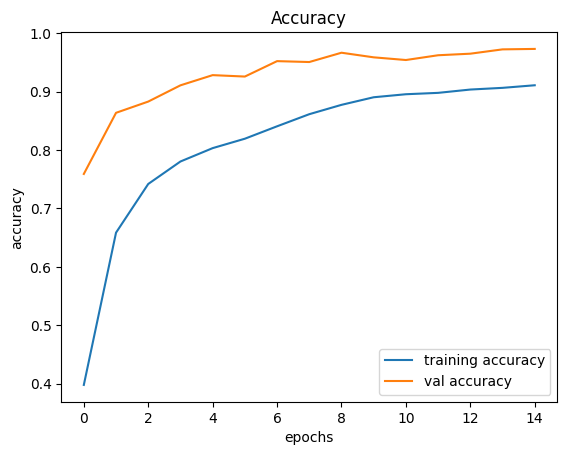

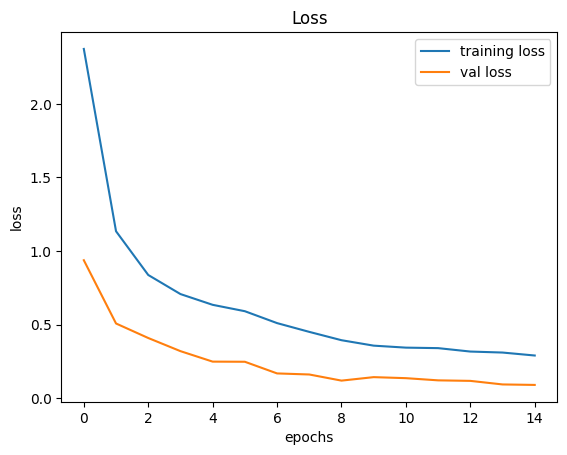

395/395 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step
0.9280285035629454


In [ ]:
data = []
labels = []
classes = 43
cur_path = path1

for i in range(classes):
    path = os.path.join(cur_path, 'Train', str(i))
    images = os.listdir(path)

    for a in images:
        try:
            image = Image.open(os.path.join(path, a))
            image = image.resize((30,30))
            image = np.array(image)
            #sim = Image.fromarray(image)
            data.append(image)
            labels.append(i)
        except:
            print("Error loading image")

data = np.array(data)
labels = np.array(labels)

print(data.shape, labels.shape)
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)

model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(43, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

epochs = 15
history = model.fit(X_train, y_train, batch_size=32, epochs=epochs, validation_data=(X_test, y_test))
model.save("my_model.h5")

plt.figure(0)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

from sklearn.metrics import accuracy_score

y_test = pd.read_csv(os.path.join(cur_path, "Test.csv"))

labels = y_test["ClassId"].values
imgs = y_test["Path"].values

data=[]

for img in imgs:
    image = Image.open(os.path.join(cur_path, img))
    image = image.resize((30,30))
    data.append(np.array(image))

X_test=np.array(data)

pred = np.argmax(model.predict(X_test), axis=1)

from sklearn.metrics import accuracy_score
print(accuracy_score(labels, pred))
